In [ ]:
# DIAGNOSTIC CELL: Run this to check your environment
import sys
print(f"Python Executable: {sys.executable}")
try:
    import numpy as np
    print(f"Numpy version: {np.__version__}")
    print("Numpy is working correctly!")
except ImportError:
    print("Numpy not found. Attempting to install in the current kernel...")
    %pip install numpy matplotlib seaborn pandas openpyxl
    print("Installation complete. PLEASE RESTART THE KERNEL (Kernel -> Restart) then run the cells again.")

Python Executable: c:\github\drl\.venv\Scripts\python.exe
Numpy version: 2.4.4
Numpy is working correctly!


# Dynamic Programming Case Study: The Race Car Problem

This notebook demonstrates the core components of Dynamic Programming (DP) — **Policy Evaluation**, **Policy Iteration**, and **Value Iteration** — applied to a classic Reinforcement Learning problem: the **Race Car MDP**.

## 1. Problem Definition

A race car agent must decide how to drive based on its engine temperature. Faster driving earns more rewards but risks overheating the engine.

### States ($S$)
- **Cool (C)**: Engine is running at optimal temperature.
- **Warm (W)**: Engine is warm but still functional.
- **Overheated (OH)**: Engine has failed (Terminal state).

### Actions ($A$)
- **Slow (S)**: Maintain a safe speed. Lower reward, lower risk.
- **Fast (F)**: Push the car. Higher reward, higher risk.

### Transition Probabilities $P(s'|s, a)$
| State ($s$) | Action ($a$) | $P(C)$ | $P(W)$ | $P(OH)$ |
|-------------|--------------|--------|--------|---------|
| Cool        | Slow         | 0.5    | 0.5    | 0.0     |
| Cool        | Fast         | 0.5    | 0.5    | 0.0     |
| Warm        | Slow         | 0.5    | 0.5    | 0.0     |
| Warm        | Fast         | 0.0    | 0.0    | 1.0     |

### Reward Function $R(s, a, s')$
- If $s'$ is non-terminal and $a$ is **Slow**: $+1$
- If $s'$ is non-terminal and $a$ is **Fast**: $+2$
- If $s'$ is **Overheated**: $-10$

### Complete Model Dynamics $p(s', r | s, a)$

| Current State ($s$) | Action ($a$) | Next State ($s'$) | Reward ($r$) | Probability ($p$) |
|:---|:---|:---|:---|:---|
| Cool | Slow | Cool | +1.0 | 0.5 |
| Cool | Slow | Warm | +1.0 | 0.5 |
| Cool | Fast | Cool | +2.0 | 0.5 |
| Cool | Fast | Warm | +2.0 | 0.5 |
| Warm | Slow | Cool | +1.0 | 0.5 |
| Warm | Slow | Warm | +1.0 | 0.5 |
| Warm | Fast | Overheated | -10.0 | 1.0 |
| Overheated | *Any* | Overheated | 0.0 | 1.0 |

### Parameters
- Discount Factor $\gamma = 0.9$

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from dataclasses import dataclass
from typing import Dict, List, Tuple

# Constants
COOL = 0
WARM = 1
OVERHEATED = 2
STATE_NAMES = {COOL: "Cool", WARM: "Warm", OVERHEATED: "Overheated"}
STATE_SYMBOLS = {COOL: "C", WARM: "W", OVERHEATED: "OH"}

SLOW = 0
FAST = 1
ACTION_NAMES = {SLOW: "Slow", FAST: "Fast"}
ACTION_SYMBOLS = {SLOW: "S", FAST: "F"}

@dataclass
class RaceCarMDP:
    num_states: int = 3
    num_actions: int = 2
    gamma: float = 0.9
    
    # P[s][a] = [(prob, next_state, reward, done), ...]
    def __post_init__(self):
        self.P = {
            COOL: {
                SLOW: [(0.5, COOL, 1.0, False), (0.5, WARM, 1.0, False)],
                FAST: [(0.5, COOL, 2.0, False), (0.5, WARM, 2.0, False)]
            },
            WARM: {
                SLOW: [(0.5, COOL, 1.0, False), (0.5, WARM, 1.0, False)],
                FAST: [(1.0, OVERHEATED, -10.0, True)]
            },
            OVERHEATED: {
                SLOW: [(1.0, OVERHEATED, 0.0, True)],
                FAST: [(1.0, OVERHEATED, 0.0, True)]
            }
        }

mdp = RaceCarMDP()

## 2. Policy Evaluation (Prediction)

How good is a given policy? We use the Bellman Expectation Equation iteratively to compute $V_\pi(s)$.

$$V_{k+1}(s) = \sum_a \pi(a|s) \sum_{s', r} p(s', r | s, a) [r + \gamma V_k(s')] \cdot (1 - \text{done})$$

**Initial Random Policy (Equiprobable):**

| State | Slow ($a=0$) | Fast ($a=1$) |
| :--- | :---: | :---: |
| **Cool** | 0.5 | 0.5 |
| **Warm** | 0.5 | 0.5 |
| **Overheated** | 0.5 | 0.5 |

In [ ]:
def policy_evaluation(mdp, policy, theta=1e-8):
    V = np.zeros(mdp.num_states)
    history = [V.copy()]
    
    while True:
        delta = 0
        for s in range(mdp.num_states):
            
            
            v_new = 0
            for a, action_prob in enumerate(policy[s]):
                for prob, next_state, reward, done in mdp.P[s][a]:
                    v_new += action_prob * prob * (reward + mdp.gamma * V[next_state] * (not done))
            
            delta = max(delta, np.abs(v_new - V[s]))
            V[s] = v_new
        
        history.append(V.copy())
        if delta < theta:
            break
    return V, history

# Uniform Random Policy: 50% Slow, 50% Fast
random_policy = np.ones((mdp.num_states, mdp.num_actions)) / mdp.num_actions
V_random, history_random = policy_evaluation(mdp, random_policy)

print("Value Function for Random Policy:")
for s in range(mdp.num_states):
    print(f"{STATE_NAMES[s]}: {V_random[s]:.4f}")

Value Function for Random Policy:
Cool: -2.6538
Warm: -6.5769
Overheated: 0.0000


## 3. Policy Iteration (Control)

Find the optimal policy by alternating between **Policy Evaluation** and **Policy Improvement**.

### Policy Improvement Step
$$\pi'(s) = \text{argmax}_a \sum_{s', r} p(s', r | s, a) [r + \gamma V_\pi(s')] \cdot (1 - \text{done})$$

In [ ]:
def policy_iteration(mdp, theta=1e-8):
    # Start with all SLOW policy
    policy = np.zeros((mdp.num_states, mdp.num_actions))
    policy[:, SLOW] = 1.0
    V = np.zeros(mdp.num_states)
    
    # Record initial state BEFORE evaluation
    policy_history = [policy.copy()]
    value_history = [V.copy()] 
    
    while True:
        # 1. Evaluation
        V, _ = policy_evaluation(mdp, policy, theta)
        
        # 2. Improvement
        policy_stable = True
        new_policy = policy.copy()
        for s in range(mdp.num_states):
            
            
            old_action = np.argmax(policy[s])
            
            action_values = np.zeros(mdp.num_actions)
            for a in range(mdp.num_actions):
                for prob, next_state, reward, done in mdp.P[s][a]:
                    action_values[a] += prob * (reward + mdp.gamma * V[next_state] * (not done))
            
            best_action = np.argmax(action_values)
            if old_action != best_action:
                policy_stable = False
                new_policy[s] = np.eye(mdp.num_actions)[best_action]
            
        # Store the Value Function computed for the current policy
        value_history.append(V.copy())
        
        if not policy_stable:
            policy = new_policy.copy()
            # Store the NEW policy derived from improvement
            policy_history.append(policy.copy())
        else:
            # Convergence
            break
            
    return policy, V, policy_history, value_history

opt_policy_pi, V_pi, pi_history, v_pi_history = policy_iteration(mdp)

print("Policy Iteration: Full Step-by-Step History")
print("Starting from Zero Value and a Cautious Policy, moving toward the Optimum.")

for i in range(len(pi_history)):
    print(f"\n--- Step {i} ---")
    p = pi_history[i]
    v = v_pi_history[i]
    
    data = []
    for s in range(mdp.num_states):
        
        pi_slow = p[s][SLOW]
        pi_fast = p[s][FAST]
        val = v[s]
        data.append([STATE_NAMES[s], f'{pi_slow:.1f}', f'{pi_fast:.1f}', f'{val:.4f}'])
    
    df_iter = pd.DataFrame(data, columns=['State', 'pi(Slow|s)', 'pi(Fast|s)', 'V(s)'])
    print(df_iter.to_string(index=False))
    
    if i == 0:
        print("(Initialization: Policy is 'Always Slow', Value is starting at 0.0)")
    else:
        print("(The policy was improved based on the values from the previous step.)")

print(f"\n--- Final Result (Step {len(pi_history)}) ---")
v_final = v_pi_history[-1]
data_final = []
for s in range(mdp.num_states):
    
    data_final.append([STATE_NAMES[s], f'{pi_history[-1][s][SLOW]:.1f}', f'{pi_history[-1][s][FAST]:.1f}', f'{v_final[s]:.4f}'])
df_final = pd.DataFrame(data_final, columns=['State', 'pi(Slow|s)', 'pi(Fast|s)', 'V(s)'])
print(df_final.to_string(index=False))
print("(Convergence: Policy is stable and values are optimal!)")

print(f"\nOptimal Policy reached after {len(pi_history)-1} improvement iterations.")

print("\n--- FINAL CONCLUSION: OPTIMAL STRATEGY ---")
final_data = []
for s in range(mdp.num_states):
    
    best_act = ACTION_NAMES[np.argmax(pi_history[-1][s])]
    final_data.append([STATE_NAMES[s], best_act])
df_final_conclusion = pd.DataFrame(final_data, columns=['State', 'Optimal Action'])
print(df_final_conclusion.to_string(index=False))

print("\n--- OPTIMAL POLICY ANALYSIS ---")
print("The final policy selection is: Cool -> FAST, Warm -> SLOW.")
print("WHY IT IS OPTIMAL:")
print("1. COOL STATE: The agent drives FAST. Since there is 0% risk of overheating from Cool (based on P),")
print("   FAST provides a higher immediate reward (+2 vs +1) without any long-term penalty risk.")
print("2. WARM STATE: The agent drives SLOW. Even though FAST gives +2 reward, it has a 100% risk of")
print("   OVERHEATING, which carries a massive penalty of -10. Driving SLOW allows the agent to")
print("   stay in the reward-earning states (Cool/Warm) indefinitely, leading to a higher discounted sum.")
print("3. STABILITY: This policy is the fixed point of the Bellman Optimality Equation; picking any")
print("   other action in any state would result in a lower expected cumulative reward (V*).")

Policy Iteration: Full Step-by-Step History
Starting from Zero Value and a Cautious Policy, moving toward the Optimum.

--- Step 0 ---
State pi(Slow|s) pi(Fast|s)   V(s)
 Cool        1.0        0.0 0.0000
 Warm        1.0        0.0 0.0000
(Initialization: Policy is 'Always Slow', Value is starting at 0.0)

--- Step 1 ---
State pi(Slow|s) pi(Fast|s)    V(s)
 Cool        0.0        1.0 10.0000
 Warm        1.0        0.0 10.0000
(The policy was improved based on the values from the previous step.)

--- Final Result (Step 2) ---
State pi(Slow|s) pi(Fast|s)    V(s)
 Cool        0.0        1.0 15.5000
 Warm        1.0        0.0 14.5000
(Convergence: Policy is stable and values are optimal!)

Optimal Policy reached after 1 improvement iterations.

--- FINAL CONCLUSION: OPTIMAL STRATEGY ---
State Optimal Action
 Cool           Fast
 Warm           Slow

--- OPTIMAL POLICY ANALYSIS ---
The final policy selection is: Cool -> FAST, Warm -> SLOW.
WHY IT IS OPTIMAL:
1. COOL STATE: The agent driv

## 4. Value Iteration (Control)

Combined sweep: Update value directly using the Bellman Optimality Equation.

$$V_{k+1}(s) = \max_a \sum_{s', r} p(s', r | s, a) [r + \gamma V_k(s')] \cdot (1 - \text{done})$$

In [ ]:
def value_iteration(mdp, theta=1e-8):
    V = np.zeros(mdp.num_states)
    history = [V.copy()]
    
    while True:
        delta = 0
        for s in range(mdp.num_states):
            
            
            v_old = V[s]
            action_values = np.zeros(mdp.num_actions)
            for a in range(mdp.num_actions):
                for prob, next_state, reward, done in mdp.P[s][a]:
                    action_values[a] += prob * (reward + mdp.gamma * V[next_state] * (not done))
            
            V[s] = np.max(action_values)
            delta = max(delta, np.abs(v_old - V[s]))
        
        history.append(V.copy())
        if delta < theta:
            break
            
    # Extract Policy
    policy = np.zeros((mdp.num_states, mdp.num_actions))
    for s in range(mdp.num_states):
        
        action_values = np.zeros(mdp.num_actions)
        for a in range(mdp.num_actions):
            for prob, next_state, reward, done in mdp.P[s][a]:
                action_values[a] += prob * (reward + mdp.gamma * V[next_state] * (not done))
        policy[s] = np.eye(mdp.num_actions)[np.argmax(action_values)]
        
    return policy, V, history

opt_policy_vi, V_vi, history_vi = value_iteration(mdp)

print("Optimal Policy (Value Iteration):")
for s in range(mdp.num_states):
    
    action = ACTION_NAMES[np.argmax(opt_policy_vi[s])]
    print(f"{STATE_NAMES[s]}: {action}")

Optimal Policy (Value Iteration):
Cool: Fast
Warm: Slow


## 5. Convergence Visualization

Observe how the value estimates for **Cool** and **Warm** states converge over time during Value Iteration.

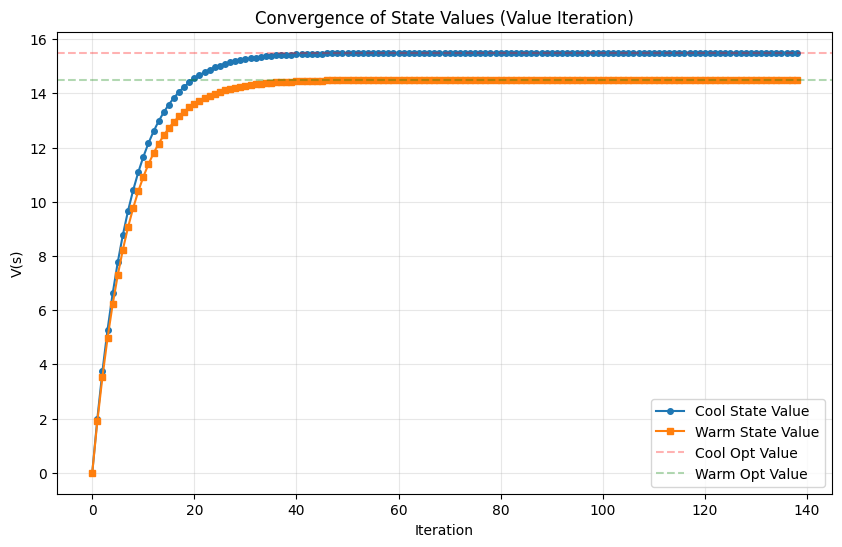

In [ ]:
history_arr = np.array(history_vi)
plt.figure(figsize=(10, 6))
plt.plot(history_arr[:, COOL], label="Cool State Value", marker='o', markersize=4)
plt.plot(history_arr[:, WARM], label="Warm State Value", marker='s', markersize=4)
plt.axhline(y=V_vi[COOL], color='r', linestyle='--', alpha=0.3, label="Cool Opt Value")
plt.axhline(y=V_vi[WARM], color='g', linestyle='--', alpha=0.3, label="Warm Opt Value")
plt.title("Convergence of State Values (Value Iteration)")
plt.xlabel("Iteration")
plt.ylabel("V(s)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 6. Summary of Results

The final converged values and optimal actions provide a clear strategy for the race car agent. 

**Key Insight**: In the **Cool** state, the agent prefers **Fast** because the risk of overheating is zero in that transition path. However, in the **Warm** state, the risk of hitting the **Overheated** terminal state (reward -10) makes **Slow** the optimal choice to sustain long-term rewards and avoid the heavy penalty.